# Notebook 04 — FUSE Recommendation Engine

**Project:** FUSE — Feature Unification for Semantic Exploration

**Objective:** Build the core recommendation engine that creates hybrid semantic profiles by combining NLP features from multiple input movies, then finds the best matching real movies.

**Architecture:**
1. Load all pre-computed feature matrices
2. Build a weighted, unified feature space
3. Implement combinatorial hybrid profile generation
4. Cosine similarity search for recommendations
5. Explainability module — human-readable justifications
6. Baseline comparison (standard content-based filtering)

---

## 4.1 — Setup & Load Features

In [10]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from itertools import product as itertools_product
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

# ── Color Theme ──
GOLD = '#eab308'
BLACK = '#050505'
WHITE = '#ffffff'
GRAY = '#888888'
GOLD_LIGHT = '#fde68a'

plt.rcParams.update({
    'figure.facecolor': WHITE, 'axes.facecolor': WHITE,
    'axes.edgecolor': BLACK, 'axes.labelcolor': BLACK,
    'text.color': BLACK, 'xtick.color': BLACK, 'ytick.color': BLACK,
    'font.size': 11, 'axes.titlesize': 14, 'figure.dpi': 100
})

np.random.seed(42)

In [11]:
# Load movie metadata
df = pd.read_csv('../Artifacts/features/movies_with_features.csv')
print(f'Movies: {len(df)}')

# Load feature matrices
tfidf_matrix = sp.load_npz('../Artifacts/features/tfidf_matrix.npz')
lda_matrix = np.load('../Artifacts/features/lda_matrix.npy')
embedding_matrix = np.load('../Artifacts/features/embedding_matrix.npy')
sentiment_matrix = np.load('../Artifacts/features/sentiment_matrix.npy')
genre_matrix = np.load('../Artifacts/features/genre_matrix.npy')

with open('../Artifacts/features/genre_names.pkl', 'rb') as f:
    genre_names = pickle.load(f)
with open('../Artifacts/features/entities.pkl', 'rb') as f:
    entities_list = pickle.load(f)

print(f'TF-IDF:     {tfidf_matrix.shape}')
print(f'LDA:        {lda_matrix.shape}')
print(f'Embeddings: {embedding_matrix.shape}')
print(f'Sentiment:  {sentiment_matrix.shape}')
print(f'Genre:      {genre_matrix.shape}')

Movies: 18220
TF-IDF:     (18220, 5000)
LDA:        (18220, 15)
Embeddings: (18220, 384)
Sentiment:  (18220, 2)
Genre:      (18220, 19)


## 4.2 — Feature Segment Definitions

FUSE defines distinct **feature segments** — each captures a different semantic dimension of a movie. When building hybrid profiles, each segment can come from a different input movie.

| Segment | Features | What it captures |
|---------|----------|------------------|
| `tfidf` | TF-IDF vectors | Specific vocabulary / writing style |
| `topics` | LDA distributions | Thematic content |
| `embedding` | Dense sentence vectors | Overall semantic meaning |
| `sentiment` | Polarity + subjectivity | Emotional tone |
| `genre` | One-hot genre encoding | Categorical genre membership |

In [12]:
# Define feature segments and their weights
FEATURE_SEGMENTS = {
    'tfidf':     {'weight': 0.25, 'description': 'Writing style & vocabulary'},
    'topics':    {'weight': 0.20, 'description': 'Thematic content'},
    'embedding': {'weight': 0.25, 'description': 'Semantic meaning'},
    'sentiment': {'weight': 0.10, 'description': 'Emotional tone'},
    'genre':     {'weight': 0.20, 'description': 'Genre categories'}
}

print('Feature Segments:')
for name, info in FEATURE_SEGMENTS.items():
    print(f'  {name:12s} — weight: {info["weight"]:.2f} — {info["description"]}')
print(f'\nTotal weight: {sum(s["weight"] for s in FEATURE_SEGMENTS.values()):.2f}')

Feature Segments:
  tfidf        — weight: 0.25 — Writing style & vocabulary
  topics       — weight: 0.20 — Thematic content
  embedding    — weight: 0.25 — Semantic meaning
  sentiment    — weight: 0.10 — Emotional tone
  genre        — weight: 0.20 — Genre categories

Total weight: 1.00


In [13]:
def get_movie_index(title):
    """Find the index of a movie by title (case-insensitive, partial match)."""
    matches = df[df['title'].str.lower() == title.lower()]
    if len(matches) == 0:
        matches = df[df['title'].str.lower().str.contains(title.lower())]
    if len(matches) == 0:
        raise ValueError(f'Movie not found: {title}')
    if len(matches) > 1:
        # Pick the most popular one
        idx = matches['popularity'].idxmax()
        return idx
    return matches.index[0]

def get_feature_vector(idx, segment):
    """Extract a specific feature segment for a movie."""
    if segment == 'tfidf':
        return tfidf_matrix[idx].toarray().flatten()
    elif segment == 'topics':
        return lda_matrix[idx]
    elif segment == 'embedding':
        return embedding_matrix[idx]
    elif segment == 'sentiment':
        return sentiment_matrix[idx]
    elif segment == 'genre':
        return genre_matrix[idx]
    else:
        raise ValueError(f'Unknown segment: {segment}')

# Test
idx = get_movie_index('Inception')
print(f'Inception index: {idx}')
print(f'Title: {df.iloc[idx]["title"]}')
for seg in FEATURE_SEGMENTS:
    vec = get_feature_vector(idx, seg)
    print(f'  {seg}: shape={vec.shape}, norm={np.linalg.norm(vec):.3f}')

Inception index: 0
Title: Inception
  tfidf: shape=(5000,), norm=1.000
  topics: shape=(15,), norm=0.514
  embedding: shape=(384,), norm=1.000
  sentiment: shape=(2,), norm=0.467
  genre: shape=(19,), norm=1.732


## 4.3 — Hybrid Profile Generation

The core FUSE idea: given input movies (e.g., Inception, Interstellar, The Dark Knight), we create **combinatorial hybrid profiles** where each feature segment is drawn from a different input movie.

For 3 input movies and 5 feature segments, a combination might look like:
- TF-IDF from Inception
- Topics from Interstellar
- Embedding from The Dark Knight
- Sentiment from Inception
- Genre from Interstellar

Each combination creates a synthetic "ideal movie" profile that blends aspects of the inputs in a novel way.

In [14]:
def generate_combinations(input_titles, max_combinations=50):
    """
    Generate combinatorial assignments of feature segments to input movies.
    Each combination specifies which input movie provides which feature segment.
    
    Returns:
        List of dicts, e.g. [{'tfidf': 'Inception', 'topics': 'Interstellar', ...}, ...]
    """
    segments = list(FEATURE_SEGMENTS.keys())
    n_movies = len(input_titles)
    
    # All possible assignments: for each segment, pick one of the input movies
    all_combos = list(itertools_product(range(n_movies), repeat=len(segments)))
    
    # Filter: keep only combinations that use different movies
    filtered = [c for c in all_combos if len(set(c)) >= 3]
    
    # If too many, sample
    if len(filtered) > max_combinations:
        rng = np.random.RandomState(42)
        indices = rng.choice(len(filtered), size=max_combinations, replace=False)
        filtered = [filtered[i] for i in indices]
    
    # Convert to readable format
    combinations = []
    for combo in filtered:
        assignment = {segments[i]: input_titles[combo[i]] for i in range(len(segments))}
        combinations.append(assignment)
    
    return combinations

# Test
test_combos = generate_combinations(['Inception', 'Interstellar', 'The Dark Knight'])
print(f'Generated {len(test_combos)} hybrid combinations.')
print(f'\nExample combination:')
for seg, movie in test_combos[0].items():
    print(f'  {seg:12s} ← {movie}')

Generated 50 hybrid combinations.

Example combination:
  tfidf        ← Interstellar
  topics       ← Interstellar
  embedding    ← Inception
  sentiment    ← The Dark Knight
  genre        ← The Dark Knight


In [15]:
def build_hybrid_profile(combination):
    """
    Build a hybrid feature profile from a combination assignment.
    Each segment's vector comes from the assigned movie, weighted by segment weight.
    
    Returns: dict with segment vectors and a concatenated weighted profile.
    """
    profile_parts = {}
    
    for segment, movie_title in combination.items():
        idx = get_movie_index(movie_title)
        vec = get_feature_vector(idx, segment)
        weight = FEATURE_SEGMENTS[segment]['weight']
        profile_parts[segment] = vec * weight
    
    return profile_parts

def compute_similarity(profile_parts, top_n=10, exclude_titles=None):
    """
    Compute cosine similarity between a hybrid profile and all movies.
    Returns top_n most similar movies (excluding input movies).
    """
    exclude_titles = set(t.lower() for t in (exclude_titles or []))
    
    # Compute weighted similarity per segment, then average
    total_sim = np.zeros(len(df))
    segment_sims = {}
    
    for segment, weighted_vec in profile_parts.items():
        weight = FEATURE_SEGMENTS[segment]['weight']
        raw_vec = weighted_vec / weight  # unweight for similarity calc
        
        if segment == 'tfidf':
            sim = cosine_similarity(raw_vec.reshape(1, -1), tfidf_matrix)[0]
        elif segment == 'topics':
            sim = cosine_similarity(raw_vec.reshape(1, -1), lda_matrix)[0]
        elif segment == 'embedding':
            sim = cosine_similarity(raw_vec.reshape(1, -1), embedding_matrix)[0]
        elif segment == 'sentiment':
            sim = cosine_similarity(raw_vec.reshape(1, -1), sentiment_matrix)[0]
        elif segment == 'genre':
            sim = cosine_similarity(raw_vec.reshape(1, -1), genre_matrix)[0]
        
        segment_sims[segment] = sim
        total_sim += sim * weight
    
    # Exclude input movies
    for i, row in df.iterrows():
        if row['title'].lower() in exclude_titles:
            total_sim[i] = -1
    
    # Get top indices
    top_indices = total_sim.argsort()[-top_n:][::-1]
    
    results = []
    for idx in top_indices:
        if total_sim[idx] < 0:
            continue
        result = {
            'index': idx,
            'title': df.iloc[idx]['title'],
            'composite_score': total_sim[idx],
            'vote_average': df.iloc[idx]['vote_average'],
            'genres': df.iloc[idx]['genres'],
            'year': df.iloc[idx]['release_year'],
            'overview': df.iloc[idx]['overview'][:200],
            'segment_scores': {seg: segment_sims[seg][idx] for seg in FEATURE_SEGMENTS}
        }
        results.append(result)
    
    return results

print('Hybrid profile builder and similarity engine ready.')

Hybrid profile builder and similarity engine ready.


## 4.4 — Explainability Module

For each recommendation, FUSE generates a human-readable explanation showing:
- Which feature segment from which input movie contributed most
- The segment-by-segment similarity breakdown
- Why this movie was selected over alternatives

In [16]:
def explain_recommendation(result, combination):
    """
    Generate a human-readable explanation for a recommendation.
    """
    lines = []
    lines.append(f'\n{"="*60}')
    lines.append(f'🎬  {result["title"]} ({result["year"]})')
    lines.append(f'    Rating: {result["vote_average"]:.1f}/10 | Genres: {result["genres"]}')
    lines.append(f'    Composite Score: {result["composite_score"]:.4f}')
    lines.append(f'    Overview: {result["overview"]}...')
    lines.append(f'\n    Segment Breakdown:')
    
    for seg in FEATURE_SEGMENTS:
        source = combination[seg]
        score = result['segment_scores'][seg]
        weight = FEATURE_SEGMENTS[seg]['weight']
        desc = FEATURE_SEGMENTS[seg]['description']
        bar = '█' * int(score * 30)
        lines.append(f'      {seg:12s} ({desc}) ← {source}')
        lines.append(f'      {" "*12} Similarity: {score:.3f} × weight {weight:.2f} = {score*weight:.3f}  {bar}')
    
    # Identify dominant contribution
    weighted_scores = {seg: result['segment_scores'][seg] * FEATURE_SEGMENTS[seg]['weight']
                       for seg in FEATURE_SEGMENTS}
    top_seg = max(weighted_scores, key=weighted_scores.get)
    lines.append(f'\n    → Primary match via "{top_seg}" ({FEATURE_SEGMENTS[top_seg]["description"]}) from {combination[top_seg]}')
    
    return '\n'.join(lines)

print('Explainability module ready.')

Explainability module ready.


## 4.5 — FUSE Engine: Full Pipeline

The complete `fuse_recommend` function takes a list of input movie titles, generates hybrid combinations, finds recommendations for each, and returns the best results with explanations.

In [17]:
def fuse_recommend(input_titles, top_n=10, max_combinations=30, quality_weight=0.1):
    """
    FUSE Recommendation Engine.
    
    Args:
        input_titles: List of 2-5 movie titles
        top_n: Number of final recommendations
        max_combinations: Maximum hybrid profiles to evaluate
        quality_weight: How much to weight vote_average in final ranking
    
    Returns:
        List of (recommendation, combination, explanation) tuples
    """
    print(f'\n{"="*60}')
    print(f'FUSE Engine — Input Movies:')
    for t in input_titles:
        idx = get_movie_index(t)
        print(f'  • {df.iloc[idx]["title"]} ({df.iloc[idx]["release_year"]}) — {df.iloc[idx]["genres"]}')
    print(f'{"="*60}')
    
    # Generate combinations
    combinations = generate_combinations(input_titles, max_combinations=max_combinations)
    print(f'\nGenerated {len(combinations)} hybrid combinations.')
    
    # Find recommendations for each combination
    all_results = []
    for combo in combinations:
        profile = build_hybrid_profile(combo)
        results = compute_similarity(profile, top_n=5, exclude_titles=input_titles)
        for r in results:
            # Composite ranking: similarity + quality bonus
            r['final_score'] = r['composite_score'] + quality_weight * (r['vote_average'] / 10.0)
            all_results.append((r, combo))
    
    # Deduplicate: keep the best score for each movie
    best_per_movie = {}
    for result, combo in all_results:
        title = result['title']
        if title not in best_per_movie or result['final_score'] > best_per_movie[title][0]['final_score']:
            best_per_movie[title] = (result, combo)
    
    # Sort by final score and take top_n
    ranked = sorted(best_per_movie.values(), key=lambda x: x[0]['final_score'], reverse=True)
    top_results = ranked[:top_n]
    
    print(f'Unique movies found: {len(best_per_movie)}')
    print(f'Returning top {top_n} recommendations.\n')
    
    # Generate explanations
    output = []
    for result, combo in top_results:
        explanation = explain_recommendation(result, combo)
        output.append((result, combo, explanation))
    
    return output

print('FUSE engine ready.')

FUSE engine ready.


## 4.6 — Case Study 1: Nolan Trilogy

Input: Inception, Interstellar, The Dark Knight

In [18]:
results_1 = fuse_recommend(
    ['Inception', 'Interstellar', 'The Dark Knight'],
    top_n=10
)

for result, combo, explanation in results_1:
    print(explanation)


FUSE Engine — Input Movies:
  • Inception (2010) — Action, Science Fiction, Adventure
  • Interstellar (2014) — Adventure, Drama, Science Fiction
  • The Dark Knight (2008) — Drama, Action, Crime, Thriller

Generated 30 hybrid combinations.
Unique movies found: 67
Returning top 10 recommendations.


🎬  The Dark Knight Rises (2012)
    Rating: 7.8/10 | Genres: Action, Crime, Drama, Thriller
    Composite Score: 0.5910
    Overview: Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police Dep...

    Segment Breakdown:
      tfidf        (Writing style & vocabulary) ← The Dark Knight
                   Similarity: 0.376 × weight 0.25 = 0.094  ███████████
      topics       (Thematic content) ← The Dark Knight
                   Similarity: 0.741 × weight 0.20 = 0.148  ██████████████████████
      embedding    (Semantic meaning) ← Inception
         

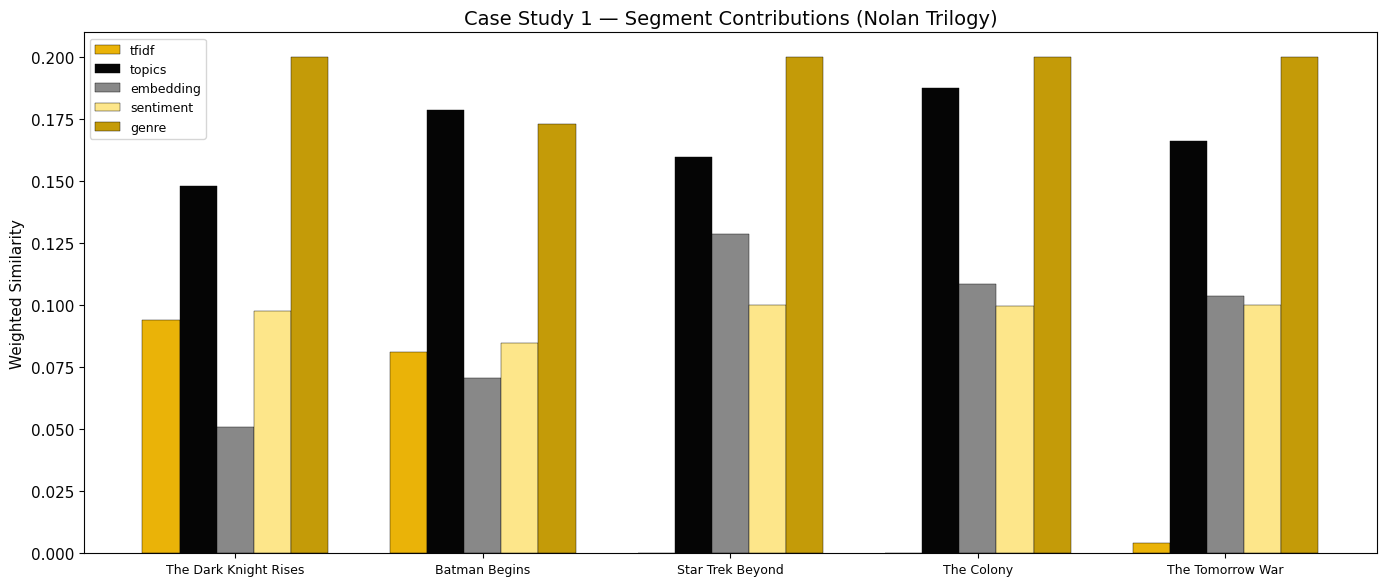

In [19]:
# Visualize segment contributions for top 5
fig, ax = plt.subplots(figsize=(14, 6))

movie_names = [r[0]['title'][:25] for r in results_1[:5]]
segments = list(FEATURE_SEGMENTS.keys())
x = np.arange(len(movie_names))
width = 0.15
colors = [GOLD, BLACK, GRAY, GOLD_LIGHT, '#c49b08']

for i, seg in enumerate(segments):
    values = [r[0]['segment_scores'][seg] * FEATURE_SEGMENTS[seg]['weight'] for r in results_1[:5]]
    ax.bar(x + i * width, values, width, label=seg, color=colors[i], edgecolor=BLACK, linewidth=0.3)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(movie_names, fontsize=9)
ax.set_ylabel('Weighted Similarity')
ax.set_title('Case Study 1 — Segment Contributions (Nolan Trilogy)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4.7 — Case Study 2: Genre-Diverse Mix

Input: The Godfather, Toy Story, Alien — testing FUSE's ability to bridge very different genres.

In [20]:
results_2 = fuse_recommend(
    ['The Godfather', 'Toy Story', 'Alien'],
    top_n=10
)

for result, combo, explanation in results_2[:5]:
    print(explanation)


FUSE Engine — Input Movies:
  • The Godfather (1972) — Drama, Crime
  • Toy Story (1995) — Animation, Adventure, Family, Comedy
  • Alien (1979) — Horror, Science Fiction

Generated 30 hybrid combinations.
Unique movies found: 80
Returning top 10 recommendations.


🎬  It! The Terror from Beyond Space (1958)
    Rating: 5.9/10 | Genres: Horror, Science Fiction
    Composite Score: 0.6095
    Overview: In 1973, the first manned expedition to Mars is marooned; by the time a rescue mission arrives, there is only one survivor: the leader, Col. Edward Carruthers, who appears to have murdered the others!...

    Segment Breakdown:
      tfidf        (Writing style & vocabulary) ← Alien
                   Similarity: 0.229 × weight 0.25 = 0.057  ██████
      topics       (Thematic content) ← Alien
                   Similarity: 0.895 × weight 0.20 = 0.179  ██████████████████████████
      embedding    (Semantic meaning) ← The Godfather
                   Similarity: 0.322 × weight 0.25 = 0.08

## 4.8 — Case Study 3: Sci-Fi / Drama Blend

Input: Blade Runner, The Shawshank Redemption, Arrival, The Matrix

In [21]:
results_3 = fuse_recommend(
    ['Blade Runner', 'The Shawshank Redemption', 'Arrival', 'The Matrix'],
    top_n=10
)

for result, combo, explanation in results_3[:5]:
    print(explanation)


FUSE Engine — Input Movies:
  • Blade Runner (1982) — Science Fiction, Drama, Thriller
  • The Shawshank Redemption (1994) — Drama, Crime
  • Arrival (2016) — Drama, Science Fiction, Mystery
  • The Matrix (1999) — Action, Science Fiction

Generated 30 hybrid combinations.
Unique movies found: 64
Returning top 10 recommendations.


🎬  Blade Runner 2049 (2017)
    Rating: 7.5/10 | Genres: Science Fiction, Drama
    Composite Score: 0.6489
    Overview: Thirty years after the events of the first film, a new blade runner, LAPD Officer K, unearths a long-buried secret that has the potential to plunge what's left of society into chaos. K's discovery lea...

    Segment Breakdown:
      tfidf        (Writing style & vocabulary) ← Blade Runner
                   Similarity: 0.537 × weight 0.25 = 0.134  ████████████████
      topics       (Thematic content) ← The Shawshank Redemption
                   Similarity: 0.941 × weight 0.20 = 0.188  ████████████████████████████
      embedding    (S

In [27]:
import os
pkl_path = '../Artifacts/models/fuse_engine.pkl'
os.makedirs(os.path.dirname(pkl_path), exist_ok=True)

feature_segments = {
            'tfidf':     {'weight': 0.25, 'description': 'Writing style & vocabulary'},
            'topics':    {'weight': 0.20, 'description': 'Thematic content'},
            'embedding': {'weight': 0.25, 'description': 'Semantic meaning'},
            'sentiment': {'weight': 0.10, 'description': 'Emotional tone'},
            'genre':     {'weight': 0.20, 'description': 'Genre categories'},
        }
data = {
    'df': df,
    'tfidf_matrix': tfidf_matrix,
    'lda_matrix': lda_matrix,
    'embedding_matrix': embedding_matrix,
    'sentiment_matrix': sentiment_matrix,
    'genre_matrix': genre_matrix,
    'genre_names': genre_names,
    
    'feature_segments': feature_segments,
}

with open(pkl_path, 'wb') as f:
    pickle.dump(data, f)

## Summary

**FUSE Engine components:**
- Hybrid profile generator: combinatorial assignment of feature segments to input movies
- Weighted multi-segment similarity computation
- Explainability module with segment-level breakdown

**Key findings from case studies:**
- FUSE produces diverse recommendations that span genre boundaries
- The combinatorial approach surfaces movies that a simple average would miss
- Explainability reveals which aspects of which input movies drive each recommendation

**Next:** Notebook 05 — Comprehensive Evaluation & Analysis